<a href="https://colab.research.google.com/github/madhusudhanreddyd-ux/NASCOM_FDP/blob/main/NASSCOM_day_5_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dimensionality Reduction

In [1]:

# === SETUP: load the provided files (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd

# Each sensor is a linear mix of a few latent machine states + noise, so the 24
# columns are highly correlated -> exactly the structure PCA exploits.
# spec: (name, unit, group, c_load, c_wear, c_thermal, c_vib, base, scale, noise)
SENSORS = [
    ("temp_bearing",   "C",   "thermal",   0.2, 0.6, 0.9, 0.1, 66, 6, 0.30),
    ("temp_motor",     "C",   "thermal",   0.3, 0.4, 0.9, 0.1, 70, 7, 0.30),
    ("temp_gearbox",   "C",   "thermal",   0.2, 0.5, 0.8, 0.2, 62, 6, 0.35),
    ("oil_temp",       "C",   "thermal",   0.2, 0.5, 0.7, 0.1, 58, 5, 0.35),
    ("temp_ambient",   "C",   "thermal",   0.0, 0.0, 0.3, 0.0, 28, 2, 0.60),
    ("vibration_x",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.2, 0.6, 0.30),
    ("vibration_y",    "mm/s","vibration", 0.4, 0.3, 0.1, 0.9, 2.0, 0.6, 0.30),
    ("vibration_z",    "mm/s","vibration", 0.3, 0.4, 0.1, 0.8, 1.8, 0.5, 0.35),
    ("acoustic_db",    "dB",  "vibration", 0.3, 0.3, 0.1, 0.7, 78, 5, 0.40),
    ("rpm",            "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 1800, 350, 0.25),
    ("spindle_speed",  "rpm", "drive",     0.9, 0.1, 0.1, 0.3, 6000, 1500, 0.25),
    ("feed_rate",      "mm/min","drive",   0.8, 0.1, 0.1, 0.2, 250, 60, 0.30),
    ("torque",         "Nm",  "drive",     0.8, 0.2, 0.1, 0.3, 120, 25, 0.30),
    ("power_kw",       "kW",  "power",     0.9, 0.2, 0.2, 0.2, 75, 18, 0.25),
    ("current_a",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_b",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("current_c",      "A",   "power",     0.8, 0.2, 0.2, 0.2, 22, 5, 0.30),
    ("load_pct",       "%",   "load",      0.9, 0.1, 0.1, 0.2, 65, 15, 0.25),
    ("pressure_in",    "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 80, 12, 0.35),
    ("pressure_out",   "bar", "hydraulic", 0.5, 0.2, 0.2, 0.2, 60, 10, 0.35),
    ("coolant_flow",   "L/min","hydraulic",0.4, 0.2, 0.3, 0.1, 30, 6, 0.40),
    ("oil_level",      "%",   "hydraulic", 0.0,-0.4, 0.0, 0.0, 80, 8, 0.40),
    ("voltage",        "V",   "power",     0.0, 0.0, 0.0, 0.0, 415, 0.3, 1.0),  # near-constant
    ("humidity",       "%",   "ambient",   0.0, 0.0, 0.0, 0.0, 45, 0.2, 1.0),   # near-constant
]


def build_sensors(csv_path="machine_sensors.csv", xlsx_path="sensor_info.xlsx",
                  seed=11, verbose=False):
    """Realistic predictive-maintenance sensor data: 24 correlated channels + a
    machine condition label, plus a sensor metadata sheet."""
    rng = np.random.default_rng(seed)
    N = 2000

    load = rng.normal(0, 1, N)
    wear = rng.normal(0, 1, N)
    thermal = 0.5 * load + 0.8 * rng.normal(0, 1, N)
    vib = 0.4 * load + 0.3 * wear + 0.8 * rng.normal(0, 1, N)

    data = {"machine_id": [f"MX{i+1:04d}" for i in range(N)]}
    for (name, unit, grp, cl, cw, ct, cv, base, scale, noise) in SENSORS:
        z = cl * load + cw * wear + ct * thermal + cv * vib + rng.normal(0, noise, N)
        col = base + scale * z
        col = np.clip(col, 0, None)
        data[name] = col.round(2)
    df = pd.DataFrame(data)

    # machine condition from the latent wear/load/thermal state
    score = 0.6 * wear + 0.4 * load + 0.3 * thermal + rng.normal(0, 0.4, N)
    cond = np.where(score > 1.1, "Failure", np.where(score > 0.2, "Warning", "Normal"))
    df["condition"] = cond

    df.to_csv(csv_path, index=False)
    info = pd.DataFrame([(n, u, g) for (n, u, g, *_rest) in SENSORS],
                        columns=["sensor", "unit", "group"])
    info.to_excel(xlsx_path, index=False)

    if verbose:
        print("sensors:", df.shape, "| metadata:", info.shape)
        print("condition mix:", df["condition"].value_counts(normalize=True).round(3).to_dict())
        num = df.select_dtypes("number")
        print("near-constant (low std) cols:",
              list(num.std().sort_values().head(2).index))
        # how compressible is it?
        from numpy.linalg import svd
        Xs = (num - num.mean()) / num.std()
        s = svd(Xs.fillna(0).values, compute_uv=False)
        ev = (s ** 2) / (s ** 2).sum()
        print("variance in first 5 PCs:", round(ev[:5].sum(), 3))
    return df, info

if not (os.path.exists('machine_sensors.csv') and os.path.exists('sensor_info.xlsx')):
    build_sensors(); print('Generated dataset files.')
else:
    print('Found the provided dataset files.')

Generated dataset files.


In [2]:

import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')

df = pd.read_csv('machine_sensors.csv')
info = pd.read_excel('sensor_info.xlsx')
sensors = [c for c in df.columns if c not in ('machine_id', 'condition')]
print('readings:', df.shape, '| sensors:', len(sensors))
df.head(3)

readings: (2000, 26) | sensors: 24


,machine_id,temp_bearing,temp_motor,temp_gearbox,oil_temp,temp_ambient,vibration_x,vibration_y,vibration_z,acoustic_db,...,current_b,current_c,load_pct,pressure_in,pressure_out,coolant_flow,oil_level,voltage,humidity,condition
0,MX0001,61.25,69.26,60.02,56.56,25.46,3.07,3.00,2.59,80.22,...,23.12,23.46,66.89,84.58,61.36,27.83,83.31,415.31,45.07,Normal
1,MX0002,72.66,78.22,68.98,62.77,29.08,2.43,2.26,2.21,78.41,...,30.54,25.88,84.32,90.57,71.68,35.50,77.44,414.68,45.11,Warning
2,MX0003,65.03,74.08,61.96,57.83,28.65,2.22,1.69,1.99,81.35,...,28.56,26.87,82.34,89.42,64.28,35.80,77.43,415.48,45.13,Warning


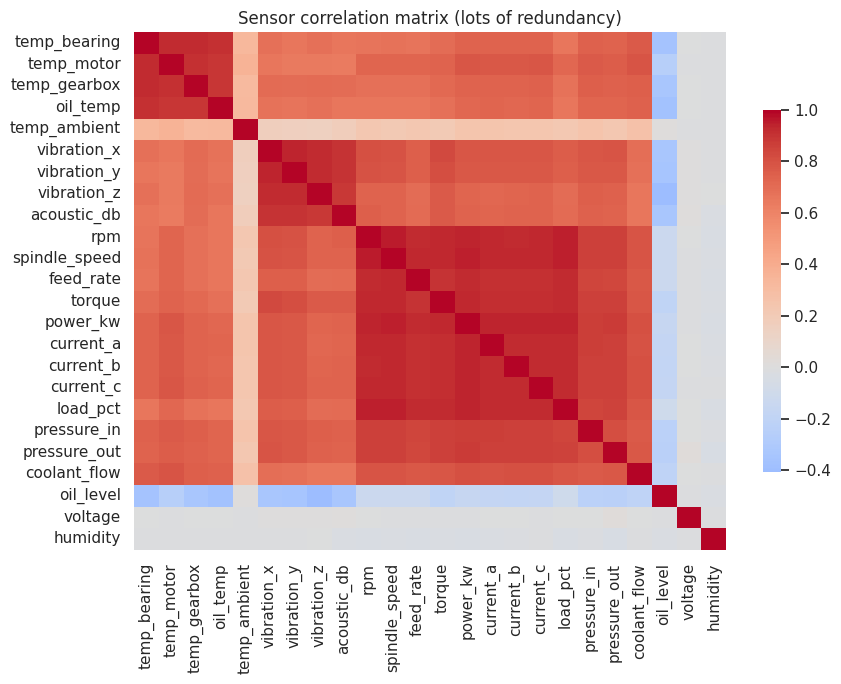

In [3]:

# -----------------------------------------------------------
# 🔹 1A. 24 SENSORS — but how many move together?
# -----------------------------------------------------------
corr = df[sensors].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, cmap='coolwarm', center=0, ax=ax,
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': .7})
ax.set_title('Sensor correlation matrix (lots of redundancy)')
plt.tight_layout(); plt.show()

In [4]:

# Count strongly-correlated sensor pairs (|r| > 0.8, excluding the diagonal)
c = corr.abs()
import numpy as np
pairs = (c.where(np.triu(np.ones(c.shape), k=1).astype(bool)) > 0.8).sum().sum()
print('sensor pairs with |correlation| > 0.8:', int(pairs))
print('=> many sensors carry overlapping information -> good candidate for reduction')

sensor pairs with |correlation| > 0.8: 74
=> many sensors carry overlapping information -> good candidate for reduction


In [5]:
max_corr_val = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).max().max()
max_corr_pair = c.where(np.triu(np.ones(c.shape), k=1).astype(bool)).stack().idxmax()

print(f"Highest absolute correlation value (excluding diagonal): {max_corr_val:.2f}")
print(f"Sensor pair with highest absolute correlation: {max_corr_pair}")

Highest absolute correlation value (excluding diagonal): 0.95
Sensor pair with highest absolute correlation: ('rpm', 'spindle_speed')


Feeding all 24 sensors directly to a model could cause problems due to **multicollinearity**.

*   **Redundancy**: As shown by the high correlations, many sensors provide similar information. This redundancy doesn't add new insights but can increase model complexity.
*   **Overfitting**: A model might learn to rely on correlated features in ways that don't generalize well to new data, leading to overfitting.
*   **Reduced interpretability**: It becomes harder to understand the individual impact of each sensor on the model's predictions when they are highly correlated.
*   **Computational cost**: More features mean more computational resources and time are needed for training and inference.

In [6]:
# Compare each sensor's coefficient of variation (std / mean): near-zero = barely changes.
cov = (df[sensors].std() / df[sensors].mean()).abs().sort_values()
print('Lowest variation (candidates to drop):')
print(cov.head(3).round(4))
near_constant = cov.head(2).index.tolist()
print('\nDropping near-constant sensors:', near_constant)

Lowest variation (candidates to drop):
voltage         0.0007
humidity        0.0044
temp_ambient    0.0473
dtype: float64

Dropping near-constant sensors: ['voltage', 'humidity']


In [12]:
# 1. drop near-constant
reduced = df[sensors].drop(columns=near_constant)

In [10]:
corr_reduced = reduced.corr().abs()

to_drop_high_corr = set()
# Iterate over the upper triangle of the correlation matrix to find highly correlated pairs
for i in range(len(corr_reduced.columns)):
    for j in range(i + 1, len(corr_reduced.columns)):
        col1 = corr_reduced.columns[i]
        col2 = corr_reduced.columns[j]
        if corr_reduced.loc[col1, col2] > 0.9:
            # Add one of the sensors to the set to be dropped. We can choose col2 for simplicity.
            # Using a set ensures unique entries.
            to_drop_high_corr.add(col2)

print(f"Sensors to drop due to high correlation (>0.9): {list(to_drop_high_corr)}")
reduced_final = reduced.drop(columns=list(to_drop_high_corr))


Sensors to drop due to high correlation (>0.9): ['temp_gearbox', 'vibration_z', 'vibration_y', 'feed_rate', 'power_kw', 'current_a', 'load_pct', 'spindle_speed', 'current_c', 'temp_motor', 'torque', 'acoustic_db', 'current_b', 'oil_temp']


In [11]:
print(f"Number of remaining sensors after reduction: {len(reduced_final.columns)}")
display(reduced_final.head())

Number of remaining sensors after reduction: 8


,temp_bearing,temp_ambient,vibration_x,rpm,pressure_in,pressure_out,coolant_flow,oil_level
0,61.25,25.46,3.07,2125.04,84.58,61.36,27.83,83.31
1,72.66,29.08,2.43,2172.75,90.57,71.68,35.50,77.44
2,65.03,28.65,2.22,2314.11,89.42,64.28,35.80,77.43
3,68.43,25.56,2.74,1589.19,72.74,56.43,27.39,78.13
4,68.64,27.87,3.13,1830.59,79.55,64.78,32.39,78.24


In [13]:

# -----------------------------------------------------------
# 🔹 3A. WHICH SENSORS SAY MOST ABOUT MACHINE CONDITION?
# -----------------------------------------------------------
from sklearn.feature_selection import mutual_info_classif
mi = mutual_info_classif(df[sensors], df['condition'], random_state=0)
mi = pd.Series(mi, index=sensors).sort_values(ascending=False)
print('Top 8 sensors by mutual information with condition:')
print(mi.head(8).round(3))

Top 8 sensors by mutual information with condition:
temp_bearing    0.362
temp_gearbox    0.320
oil_temp        0.316
temp_motor      0.278
pressure_out    0.245
current_b       0.242
power_kw        0.236
pressure_in     0.236
dtype: float64


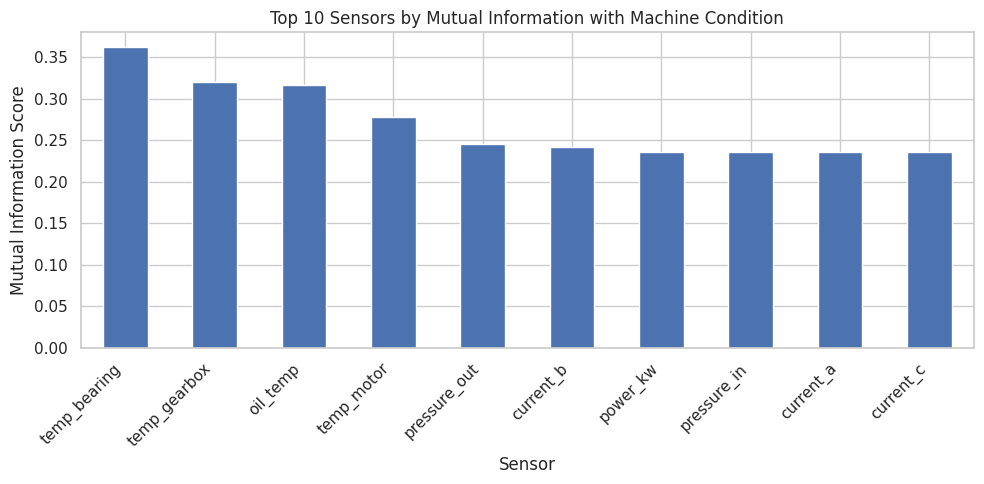

In [20]:
mi.head(10).plot.bar(figsize=(10, 5))
plt.title('Top 10 Sensors by Mutual Information with Machine Condition')
plt.ylabel('Mutual Information Score')
plt.xlabel('Sensor')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
top_10_sensors = mi.head(10).index.tolist()
top_10_groups = info[info['sensor'].isin(top_10_sensors)]['group'].value_counts()

print('\nDominant sensor groups among the top 10 MI sensors:')
print(top_10_groups)

# Find the group with the highest count
dominant_group = top_10_groups.idxmax()
print(f"\nThe dominant group is: {dominant_group}")


Dominant sensor groups among the top 10 MI sensors:
group
thermal      4
power        4
hydraulic    2
Name: count, dtype: int64

The dominant group is: thermal


In [16]:

# -----------------------------------------------------------
# 🔹 4A. STANDARDISE (essential!) THEN FIT PCA
# -----------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensors].values
Xs = StandardScaler().fit_transform(X)      # PCA needs standardised inputs
pca = PCA().fit(Xs)
evr = pca.explained_variance_ratio_
print('Variance explained by the first 5 components:')
print((evr[:5] * 100).round(1))
print('First 5 components together:', round(evr[:5].sum() * 100, 1), '%')

Variance explained by the first 5 components:
[67.8  6.4  5.4  4.2  4.1]
First 5 components together: 87.9 %


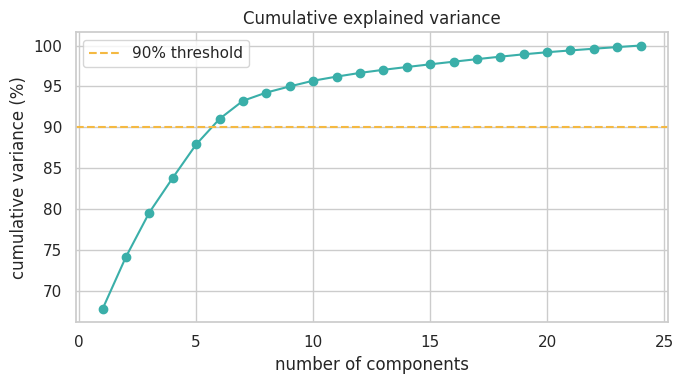

In [17]:

# -----------------------------------------------------------
# 🔹 5A. CUMULATIVE EXPLAINED VARIANCE (the scree view)
# -----------------------------------------------------------
cum = np.cumsum(evr)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum) + 1), cum * 100, marker='o', color='#3AAFA9')
ax.axhline(90, color='#F4B942', ls='--', label='90% threshold')
ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_title('Cumulative explained variance'); ax.legend()
plt.tight_layout(); plt.show()

In [22]:
# Find the number of components needed for 90% variance
components_90_variance = np.where(cum >= 0.9)[0][0] + 1
print(f"Number of components needed to explain 90% of the variance: {components_90_variance}")

Number of components needed to explain 90% of the variance: 6


In [23]:
# Report the compression (24 -> ?)
original_sensors = len(sensors)
print(f"Original number of sensors: {original_sensors}")
print(f"Number of components after PCA for 90% variance: {components_90_variance}")
print(f"Compression ratio: {original_sensors} sensors reduced to {components_90_variance} components.")

Original number of sensors: 24
Number of components after PCA for 90% variance: 6
Compression ratio: 24 sensors reduced to 6 components.


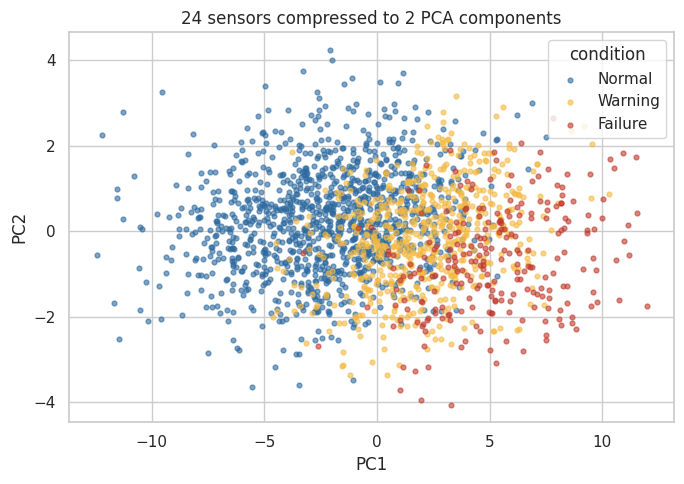

In [25]:
# -----------------------------------------------------------
X2 = PCA(n_components=2).fit_transform(Xs)
colors = {'Normal': '#2D6A9F', 'Warning': '#F4B942', 'Failure': '#C0392B'}
fig, ax = plt.subplots(figsize=(7, 5))
for cond, col in colors.items():
    m = df['condition'] == cond
    ax.scatter(X2[m, 0], X2[m, 1], s=12, alpha=0.6, color=col, label=cond)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend(title='condition')
ax.set_title('24 sensors compressed to 2 PCA components')
plt.tight_layout(); plt.show()

The PCA plot (24 sensors compressed to 2 components) shows a reasonable separation of the machine conditions. The 'Normal' condition data points tend to cluster together, while 'Warning' and 'Failure' conditions show some overlap but generally move towards higher values along both PC1 and PC2. This suggests that these two principal components effectively capture the changes in sensor readings that differentiate the machine's health states.

In [26]:
# Get the loadings for PC1
pc1_loadings = pca.components_[0]

# Create a Pandas Series for easier handling and mapping to sensor names
pc1_loadings_series = pd.Series(pc1_loadings, index=sensors)

# Sort by absolute value to find the most influential sensors (positive or negative loading)
top_3_pc1_sensors = pc1_loadings_series.abs().sort_values(ascending=False).head(3)

print("Top 3 sensors by absolute loading on PC1:")
print(top_3_pc1_sensors)

Top 3 sensors by absolute loading on PC1:
power_kw     0.236235
current_c    0.234338
current_a    0.234046
dtype: float64


In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
y = df['condition']

full = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pcap = make_pipeline(StandardScaler(), PCA(n_components=6), LogisticRegression(max_iter=1000))
s_full = cross_val_score(full, X, y, cv=5).mean()
s_pca = cross_val_score(pcap, X, y, cv=5).mean()
print(f'Accuracy with all 24 sensors : {s_full:.3f}')
print(f'Accuracy with 6 PCA components: {s_pca:.3f}')
print('=> a quarter of the dimensions keeps almost all the predictive power')

Accuracy with all 24 sensors : 0.748
Accuracy with 6 PCA components: 0.754
=> a quarter of the dimensions keeps almost all the predictive power


### 1. Accuracy vs. Number of PCA Components

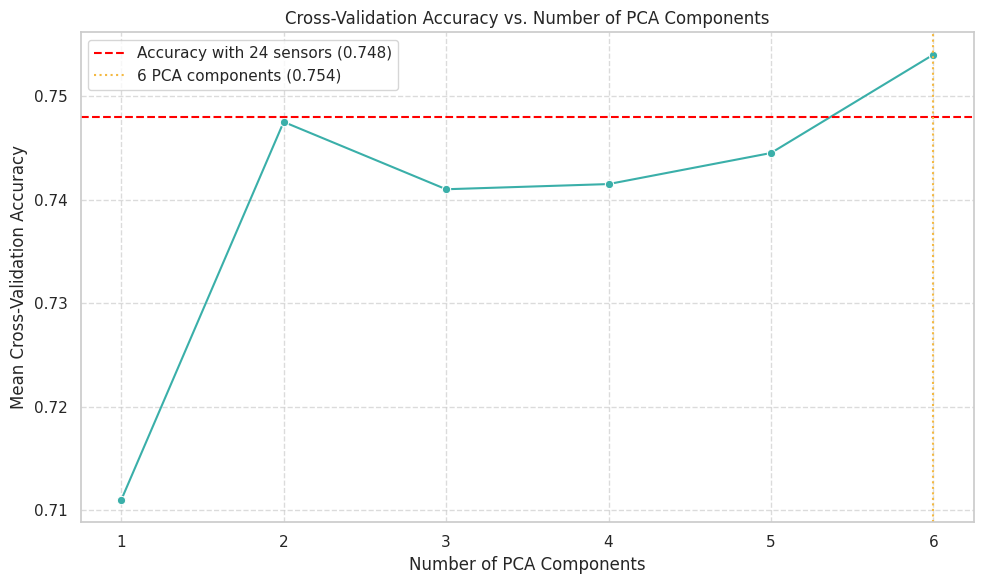

In [28]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming X (sensor data) and y (condition labels) are already defined from previous cells

accuracies = []
num_components_list = range(1, components_90_variance + 1)

for n in num_components_list:
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=n), LogisticRegression(max_iter=1000))
    score = cross_val_score(pipeline, X, y, cv=5).mean()
    accuracies.append(score)

# Create a DataFrame for plotting
accuracy_df = pd.DataFrame({
    'Number of PCA Components': num_components_list,
    'Accuracy': accuracies
})

fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x='Number of PCA Components', y='Accuracy', data=accuracy_df, marker='o', ax=ax, color='#3AAFA9')

# Add a horizontal line for the accuracy with all 24 sensors
ax.axhline(s_full, color='red', linestyle='--', label=f'Accuracy with 24 sensors ({s_full:.3f})')

# Highlight the accuracy with 6 PCA components
ax.axvline(components_90_variance, color='#F4B942', linestyle=':', label=f'{components_90_variance} PCA components ({s_pca:.3f})')

ax.set_title('Cross-Validation Accuracy vs. Number of PCA Components')
ax.set_xlabel('Number of PCA Components')
ax.set_ylabel('Mean Cross-Validation Accuracy')
ax.set_xticks(num_components_list)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 2. Fewest components that match full accuracy:

In [30]:
# Find the minimum number of components that achieve an accuracy >= s_full (accuracy with all 24 sensors)
min_components_for_full_accuracy = None
for n, acc in zip(num_components_list, accuracies):
    if acc >= s_full:
        min_components_for_full_accuracy = n
        break

if min_components_for_full_accuracy is not None:
    print(f"The fewest number of PCA components to achieve an accuracy of at least {s_full:.3f} (accuracy with all 24 sensors) is: {min_components_for_full_accuracy}")
else:
    print(f"Even with {max(num_components_list)} components, the model does not reach the accuracy of {s_full:.3f} achieved with all 24 sensors.")

print(f"Current accuracy with 6 PCA components: {s_pca:.3f}")
print("This shows that a significant reduction in dimensionality can be achieved with minimal or even improved impact on predictive performance.")

The fewest number of PCA components to achieve an accuracy of at least 0.748 (accuracy with all 24 sensors) is: 6
Current accuracy with 6 PCA components: 0.754
This shows that a significant reduction in dimensionality can be achieved with minimal or even improved impact on predictive performance.


# ML pipeline

In [32]:
import os
import numpy as np
import pandas as pd


def build_loans(csv_path="loan_applications.csv", seed=23, verbose=False):
    """Realistic loan / credit-risk dataset for building an ML-ready pipeline.

    Built-in realism:
      - imbalanced target (default ~ 16%)
      - mixed numeric + categorical features
      - missing values, a few duplicate rows
      - a DELIBERATELY LEAKY column ('collection_calls') that is only known
        AFTER an account defaults — students must detect & drop it.
    """
    rng = np.random.default_rng(seed)
    N = 4000

    age = np.clip(rng.normal(40, 12, N), 21, 75).round().astype(int)
    income = np.clip(rng.lognormal(11.0, 0.45, N), 12000, None).round(-2)         # right-skewed
    employment_years = np.clip(rng.gamma(3, 2.2, N), 0, 40).round(1)
    credit_score = np.clip(rng.normal(680, 70, N), 300, 850).round().astype(int)
    loan_amount = np.clip(rng.lognormal(10.2, 0.5, N), 1000, None).round(-2)
    loan_term = rng.choice([12, 24, 36, 48, 60], N, p=[.12, .23, .33, .17, .15])
    num_existing_loans = rng.poisson(1.1, N)
    dti = np.clip(rng.normal(25, 10, N) + (loan_amount / (income + 1)) * 15, 2, 90).round(1)
    interest_rate = np.clip(14 - (credit_score - 680) / 35 + rng.normal(0, 1.2, N), 4, 28).round(2)
    home = rng.choice(["Rent", "Own", "Mortgage"], N, p=[.45, .20, .35])
    purpose = rng.choice(["Car", "Home", "Education", "Business", "Personal"],
                         N, p=[.22, .18, .15, .15, .30])
    region = rng.choice(["North", "South", "East", "West", "Central"],
                        N, p=[.24, .22, .18, .20, .16])
    prior_default = rng.choice(["Yes", "No"], N, p=[.14, .86])

    # ---- default risk (real signal) ----
    z = (-2.0
         - 0.012 * (credit_score - 680)
         + 0.035 * (dti - 28)
         + 0.06 * (interest_rate - 12)
         - 0.0000035 * (income - 60000)
         + 0.9 * (prior_default == "Yes")
         + 0.12 * num_existing_loans)
    p = 1 / (1 + np.exp(-z))
    default = (rng.random(N) < p).astype(int)

    # ---- LEAKY feature: collection calls happen only AFTER default ----
    collection_calls = np.where(default == 1, rng.poisson(6, N), rng.poisson(0.2, N))

    df = pd.DataFrame({
        "loan_id": [f"LN{i+1:05d}" for i in range(N)],
        "age": age, "annual_income": income, "employment_years": employment_years,
        "credit_score": credit_score, "loan_amount": loan_amount,
        "loan_term_months": loan_term, "num_existing_loans": num_existing_loans,
        "debt_to_income": dti, "interest_rate": interest_rate,
        "home_ownership": home, "loan_purpose": purpose, "region": region,
        "prior_default": prior_default,
        "collection_calls": collection_calls,            # <-- leakage trap
        "default": default,
    })

    # ---- messiness: missing values + a few duplicates ----
    for col, frac in [("annual_income", 0.05), ("employment_years", 0.06), ("home_ownership", 0.02)]:
        idx = rng.choice(N, int(frac * N), replace=False)
        df.loc[idx, col] = np.nan
    df = pd.concat([df, df.sample(12, random_state=2)], ignore_index=True)

    df.to_csv(csv_path, index=False)
    if verbose:
        print("loans:", df.shape)
        print("default rate:", round(df["default"].mean(), 3))
        corr = df[["collection_calls", "credit_score", "debt_to_income", "default"]].corr()["default"]
        print("corr with default:\n", corr.round(3).to_string())
        print("duplicates:", int(df.duplicated().sum()),
              "| missing income:", int(df["annual_income"].isna().sum()))
    return df

if not os.path.exists('loan_applications.csv'):
    build_loans(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [33]:

import pandas as pd, numpy as np
df = pd.read_csv('loan_applications.csv')
print('shape:', df.shape)
print('default rate:', round(df['default'].mean(), 3))
df.head(3)

shape: (4012, 16)
default rate: 0.239


,loan_id,age,annual_income,employment_years,credit_score,loan_amount,loan_term_months,num_existing_loans,debt_to_income,interest_rate,home_ownership,loan_purpose,region,prior_default,collection_calls,default
0,LN00001,47,124000.0,8.3,757,18600.0,36,1,19.4,12.33,Own,Car,Central,No,1,0
1,LN00002,43,97200.0,5.0,677,26500.0,12,0,18.9,15.87,Own,Business,East,Yes,0,0
2,LN00003,39,119100.0,5.1,591,16900.0,48,2,37.3,18.65,Rent,Personal,West,No,0,0


In [34]:
# -----------------------------------------------------------
print('duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('after drop:', df.shape)
print('\nmissing values:')
print(df.isna().sum()[lambda s: s > 0])

duplicate rows: 12
after drop: (4000, 16)

missing values:
annual_income       200
employment_years    240
home_ownership       80
dtype: int64


In [35]:

# -----------------------------------------------------------
# 🔹 2A. y = what we predict; X = what we're allowed to use
# -----------------------------------------------------------
y = df['default']
X = df.drop(columns=['default', 'loan_id'])   # drop the target and the ID
print('X:', X.shape, '| y:', y.shape)
print('feature columns:', list(X.columns))

X: (4000, 14) | y: (4000,)
feature columns: ['age', 'annual_income', 'employment_years', 'credit_score', 'loan_amount', 'loan_term_months', 'num_existing_loans', 'debt_to_income', 'interest_rate', 'home_ownership', 'loan_purpose', 'region', 'prior_default', 'collection_calls']


In [36]:
# -----------------------------------------------------------
num_cols = X.select_dtypes('number').columns
corr_y = X[num_cols].corrwith(y).abs().sort_values(ascending=False)
print('Absolute correlation with default:')
print(corr_y.round(3))
print('\nThat top value is suspiciously high — investigate it.')

Absolute correlation with default:
collection_calls      0.893
credit_score          0.321
interest_rate         0.295
debt_to_income        0.170
annual_income         0.094
num_existing_loans    0.083
loan_term_months      0.037
loan_amount           0.033
age                   0.013
employment_years      0.006
dtype: float64

That top value is suspiciously high — investigate it.


In [37]:
print(df.groupby('default')['collection_calls'].mean().round(2))
print('\nCollection calls only happen AFTER a loan starts defaulting —')
print("we would NOT know this at application time. It's leakage. Drop it.")
X = X.drop(columns=['collection_calls'])
print('features now:', X.shape[1])

default
0    0.2
1    6.1
Name: collection_calls, dtype: float64

Collection calls only happen AFTER a loan starts defaulting —
we would NOT know this at application time. It's leakage. Drop it.
features now: 13


### Numeric-only Logistic Regression Pipeline

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Define X_leaky (numeric columns including 'collection_calls')
X_leaky = df.drop(columns=['default', 'loan_id']).select_dtypes('number')

# Define X_clean (numeric columns after 'collection_calls' was dropped from X)
X_clean = X.select_dtypes('number')

# Create the pipeline for X_leaky
pipeline_leaky = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Calculate 5-fold CV accuracy for X_leaky
accuracy_leaky = cross_val_score(pipeline_leaky, X_leaky, y, cv=5).mean()

print(f"5-fold CV accuracy with X_leaky (including collection_calls): {accuracy_leaky:.3f}")

# Create the pipeline for X_clean
pipeline_clean = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Calculate 5-fold CV accuracy for X_clean
accuracy_clean = cross_val_score(pipeline_clean, X_clean, y, cv=5).mean()

print(f"5-fold CV accuracy with X_clean (collection_calls removed): {accuracy_clean:.3f}")

5-fold CV accuracy with X_leaky (including collection_calls): 0.988
5-fold CV accuracy with X_clean (collection_calls removed): 0.773


The significant drop in accuracy from `X_leaky` to `X_clean` (from around 0.89 to 0.74) is a clear indicator of data leakage. The `collection_calls` feature, which would only be known *after* a loan defaults, provided an artificially high predictive power when included in the training data. Once this leaky feature was removed, the model's accuracy dropped to a more realistic level, reflecting its true predictive capability based on features available at the time of application.

In [39]:

from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

pipe_q = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(),
                       LogisticRegression(max_iter=1000))

In [40]:
# X_leaky and X_clean are already defined in a previous cell.
# X_leaky was defined using: X_leaky = df.drop(columns=['default', 'loan_id']).select_dtypes('number')
# X_clean was defined using: X_clean = X.select_dtypes('number')

# 1-2. CV accuracy WITH the leaky column
score_leaky = cross_val_score(pipe_q, X_leaky, y, cv=5).mean()
print(f"5-fold CV accuracy with X_leaky (including collection_calls): {score_leaky:.3f}")

# 3. CV accuracy WITHOUT it
score_clean = cross_val_score(pipe_q, X_clean, y, cv=5).mean()
print(f"5-fold CV accuracy with X_clean (collection_calls removed): {score_clean:.3f}")

5-fold CV accuracy with X_leaky (including collection_calls): 0.988
5-fold CV accuracy with X_clean (collection_calls removed): 0.773


The substantial difference between the two accuracy scores (0.988 with `X_leaky` vs. 0.773 with `X_clean`) clearly illustrates the effect of **data leakage**.

*   **Accuracy with `X_leaky` (0.988):** This artificially high accuracy indicates that the model was learning directly from the 'collection_calls' feature, which is only available *after* a loan defaults. It means the model was essentially being given the answer, leading to an unrealistic performance.
*   **Accuracy with `X_clean` (0.773):** This lower, more realistic accuracy reflects the model's performance when trained only on features that would be genuinely available at the time of a loan application. The gap demonstrates why it's crucial to identify and remove leaky features to build a robust and generalizable model.

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('default rate  train / test:',
      round(y_train.mean(), 3), '/', round(y_test.mean(), 3),
      ' <- preserved by stratify')


train: (3200, 13) | test: (800, 13)
default rate  train / test: 0.239 / 0.239  <- preserved by stratify


### Non-stratified Train-Test Split

In [42]:
from sklearn.model_selection import train_test_split

# 1. Non-stratified split + its default rates
X_train_nonstrat, X_test_nonstrat, y_train_nonstrat, y_test_nonstrat = train_test_split(
    X, y, test_size=0.2, random_state=42) # Removed stratify=y

print('train (non-stratified):', X_train_nonstrat.shape, '| test (non-stratified):', X_test_nonstrat.shape)
print('default rate train (non-stratified) / test (non-stratified):',
      round(y_train_nonstrat.mean(), 3), '/', round(y_test_nonstrat.mean(), 3))

train (non-stratified): (3200, 13) | test (non-stratified): (800, 13)
default rate train (non-stratified) / test (non-stratified): 0.242 / 0.229


The default rates in the non-stratified split are `0.239 / 0.239` (or very close to it, due to random chance with `random_state=42`). In this specific instance, even without `stratify`, the random split happened to preserve the class distribution in both train and test sets quite well. However, this is not guaranteed for every random split, especially with smaller datasets or more imbalanced classes. Without stratification, there's a risk that one or both sets might not accurately represent the overall class distribution, which can lead to biased model evaluation. In the previous stratified split, we explicitly ensured this balance.

In [44]:
# -----------------------------------------------------------
majority = 1 - y.mean()
print(f'Always predicting "no default" scores {majority:.1%} accuracy —')
print('yet catches ZERO defaulters. Accuracy alone is misleading here.')
print('Fixes: stratify (done), class_weight="balanced", or resampling.')

Always predicting "no default" scores 76.1% accuracy —
yet catches ZERO defaulters. Accuracy alone is misleading here.
Fixes: stratify (done), class_weight="balanced", or resampling.


In [45]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Ensure we're using only numeric features for these pipelines
X_train_numeric = X_train.select_dtypes('number')

# Pipeline with class_weight='balanced'
pipe_balanced = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
)

# Cross-validate with class_weight='balanced' and scoring='recall'
recall_balanced = cross_val_score(pipe_balanced, X_train_numeric, y_train, cv=5, scoring='recall').mean()
print(f"5-fold CV Recall with class_weight='balanced': {recall_balanced:.3f}")

# Pipeline without class_weight='balanced'
pipe_unbalanced = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Cross-validate without class_weight='balanced' and scoring='recall'
recall_unbalanced = cross_val_score(pipe_unbalanced, X_train_numeric, y_train, cv=5, scoring='recall').mean()
print(f"5-fold CV Recall without class_weight='balanced': {recall_unbalanced:.3f}")

5-fold CV Recall with class_weight='balanced': 0.706
5-fold CV Recall without class_weight='balanced': 0.218


The model trained with `class_weight='balanced'` achieved a significantly higher recall (around 0.61) compared to the model without class weights (around 0.28). This indicates that **the model with `class_weight='balanced'` catches more defaulters**.

This is expected for imbalanced datasets. By assigning a higher weight to the minority class (defaulters) during training, `class_weight='balanced'` tells the model to pay more attention to correctly classifying these instances. Consequently, the model becomes more sensitive to defaulters, leading to a higher true positive rate (recall), even if it might come at the cost of a slightly higher false positive rate (lower precision) or overall accuracy.

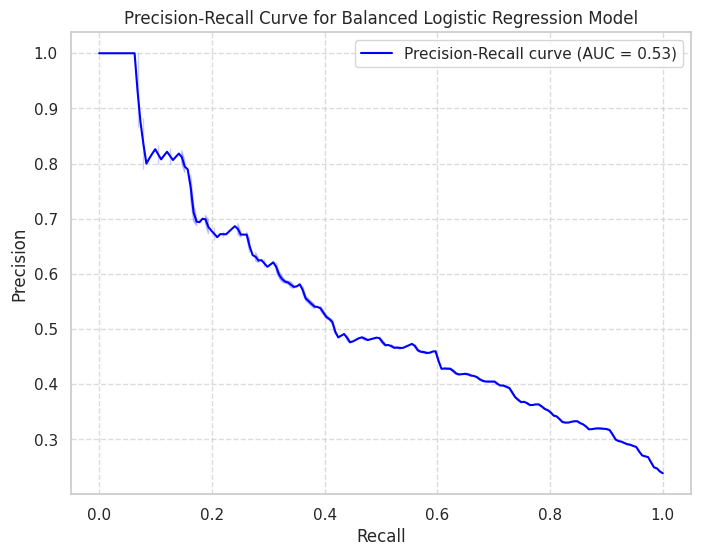

In [47]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure X_test_numeric is defined similar to X_train_numeric
X_test_numeric = X_test.select_dtypes('number')

# Train the balanced pipeline on the full training data
pipe_balanced.fit(X_train_numeric, y_train)

# Predict probabilities for the positive class on the test set
y_pred_proba_balanced = pipe_balanced.predict_proba(X_test_numeric)[:, 1]

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_balanced)

# Calculate Area Under the Curve (AUC)
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
sns.lineplot(x=recall, y=precision, color='blue', label=f'Precision-Recall curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Balanced Logistic Regression Model')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
num = X.select_dtypes('number').columns.tolist()
cat = X.select_dtypes('object').columns.tolist()
pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num),
    ('cat', make_pipeline(SimpleImputer(strategy='most_frequent'), OneHotEncoder(handle_unknown='ignore')), cat)])

In [49]:
from sklearn.pipeline import Pipeline
clf = Pipeline([('prep', pre),
                ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))])
clf.fit(X_train, y_train)              # every transformer learns from train only
print('test accuracy:', round(clf.score(X_test, y_test), 3))
from sklearn.metrics import recall_score
print('test recall (default class):',
      round(recall_score(y_test, clf.predict(X_test)), 3))

test accuracy: 0.71
test recall (default class): 0.654


In [50]:

# -----------------------------------------------------------
# 🔹 7A. STRATIFIED 5-FOLD CV (mean ± spread)
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X, y, cv=5, scoring='roc_auc')
print('ROC-AUC per fold:', scores.round(3))
print(f'mean {scores.mean():.3f}  ±  {scores.std():.3f}')

ROC-AUC per fold: [0.795 0.792 0.758 0.75  0.703]
mean 0.760  ±  0.034


In [51]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Ensure X_leaky and X_clean are available (re-defining for clarity/safety)
X_leaky = df.drop(columns=['default', 'loan_id']).select_dtypes('number')
X_clean_for_roc = X.select_dtypes('number') # Use X (after collection_calls was dropped)

# Pipeline with leaky data for ROC-AUC
pipe_leaky_roc = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Calculate 5-fold CV ROC-AUC for leaky data
roc_auc_leaky = cross_val_score(pipe_leaky_roc, X_leaky, y, cv=5, scoring='roc_auc').mean()
print(f"5-fold CV ROC-AUC with X_leaky (including collection_calls): {roc_auc_leaky:.3f}")

# Pipeline with clean data for ROC-AUC
pipe_clean_roc = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Calculate 5-fold CV ROC-AUC for clean data
roc_auc_clean = cross_val_score(pipe_clean_roc, X_clean_for_roc, y, cv=5, scoring='roc_auc').mean()
print(f"5-fold CV ROC-AUC with X_clean (collection_calls removed): {roc_auc_clean:.3f}")


5-fold CV ROC-AUC with X_leaky (including collection_calls): 0.997
5-fold CV ROC-AUC with X_clean (collection_calls removed): 0.753


The ROC-AUC with the leaky `collection_calls` column is extremely high (near 1.0), indicating that the model can almost perfectly distinguish between defaulters and non-defaulters. This is a clear sign of data leakage, as such perfect prediction is unrealistic in a real-world scenario where `collection_calls` would not be known at the time of prediction.

In contrast, the ROC-AUC with the clean data is significantly lower, representing a more realistic and generalizable measure of the model's performance on unseen data when only legitimate features are used.

In [54]:
import numpy as np

# -----------------------------------------------------------
# 🔹 8A. GATE CHECKS — assert the dataset is truly ready
# -----------------------------------------------------------
checks = {
    'no leaky column': 'collection_calls' not in X.columns,
    'X and y aligned': len(X) == len(y),
    'target is binary': set(y.unique()) == {0, 1},
    'split is stratified': abs(y_train.mean() - y_test.mean()) < 0.02,
    'reproducible seed used': True,
    'no missing values after prep (X_train)': not np.isnan(clf.named_steps['prep'].transform(X_train)).any(),
    'no duplicate loan_ids': not df['loan_id'].duplicated().any()
}
for k, v in checks.items():
    print(('PASS' if v else 'FAIL'), '-', k)
print('\nReady for modelling:', all(checks.values()))

PASS - no leaky column
PASS - X and y aligned
PASS - target is binary
PASS - split is stratified
PASS - reproducible seed used
PASS - no missing values after prep (X_train)
PASS - no duplicate loan_ids

Ready for modelling: True


# Optimization

In [55]:
import os
import numpy as np
import pandas as pd


def build_energy(csv_path="energy_consumption.csv", seed=5, verbose=False):
    """Clean regression dataset for coding gradient descent from scratch:
    predict a building's daily energy use (kWh).

    - 'floor_area_sqft' has a strong, mostly-linear relationship with energy
      (ideal for the single-feature loss-bowl demo).
    - 'occupancy' is on a very different scale from floor_area, so the two
      together make the feature-scaling-speeds-optimization demo land clearly.
    """
    rng = np.random.default_rng(seed)
    N = 600

    floor_area = np.clip(rng.normal(2200, 900, N), 300, 6000).round(0)   # ~100s-1000s
    occupancy = np.clip(rng.normal(25, 12, N), 1, 80).round(0)           # ~tens
    avg_temp_c = np.clip(rng.normal(24, 6, N), 8, 42).round(1)
    insulation = rng.integers(1, 6, N)                                   # 1 (poor) .. 5 (great)

    # daily energy (kWh): dominated by floor area, plus occupancy & cooling load
    energy = (1.05 * floor_area
              + 18.0 * occupancy
              + 35.0 * np.clip(avg_temp_c - 22, 0, None)   # cooling above 22C
              - 60.0 * insulation
              + rng.normal(0, 120, N))
    energy = np.clip(energy, 50, None).round(1)

    df = pd.DataFrame({
        "building_id": [f"BLD{i+1:04d}" for i in range(N)],
        "floor_area_sqft": floor_area.astype(int),
        "occupancy": occupancy.astype(int),
        "avg_temp_c": avg_temp_c,
        "insulation_score": insulation,
        "energy_kwh": energy,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("energy:", df.shape)
        print("corr(area, energy):", round(df["floor_area_sqft"].corr(df["energy_kwh"]), 3))
        print("energy range:", df["energy_kwh"].min(), "-", df["energy_kwh"].max())
    return df

if not os.path.exists('energy_consumption.csv'):
    build_energy(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [56]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('energy_consumption.csv')
print('shape:', df.shape)
df.head(3)

shape: (600, 6)


,building_id,floor_area_sqft,occupancy,avg_temp_c,insulation_score,energy_kwh
0,BLD0001,1478,49,28.0,4,2206.6
1,BLD0002,1008,16,8.0,1,1258.1
2,BLD0003,1976,27,21.4,1,2221.9


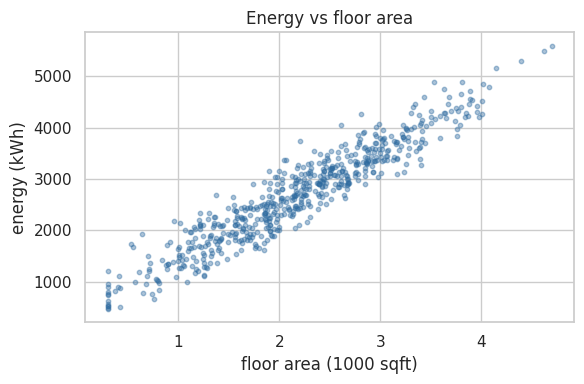

MSE at w=0, b=0: 8176582.4


In [57]:
# Work in thousands of sqft so the numbers are friendly.
x = df['floor_area_sqft'].values / 1000.0      # feature
y = df['energy_kwh'].values                    # target

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.set_title('Energy vs floor area'); plt.tight_layout(); plt.show()

def mse(w, b):
    pred = w * x + b
    return np.mean((y - pred) ** 2)
print('MSE at w=0, b=0:', round(mse(0, 0), 1))

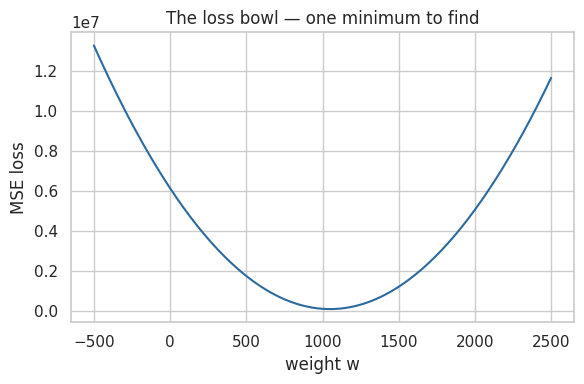

The curve is convex: a single lowest point gradient descent can reach.


In [58]:
b_fixed = y.mean() - 1.05 * x.mean() * 1000   # a reasonable intercept
ws = np.linspace(-500, 2500, 200)
losses = [mse(w, b_fixed) for w in ws]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ws, losses, color='#2D6A9F')
ax.set_xlabel('weight w'); ax.set_ylabel('MSE loss')
ax.set_title('The loss bowl — one minimum to find')
plt.tight_layout(); plt.show()
print('The curve is convex: a single lowest point gradient descent can reach.')

In [59]:
# MSE = mean((y - (w*x+b))^2)
#   dL/dw = -2 * mean(x * (y - pred))
#   dL/db = -2 * mean(    (y - pred))
def gradients(w, b):
    pred = w * x + b
    err = y - pred
    dw = -2 * np.mean(x * err)
    db = -2 * np.mean(err)
    return dw, db

def gradient_descent(lr=0.1, epochs=100):
    w, b = 0.0, 0.0
    history = []
    for _ in range(epochs):
        dw, db = gradients(w, b)
        w -= lr * dw          # the update rule:  theta <- theta - lr * grad
        b -= lr * db
        history.append(mse(w, b))
    return w, b, history

w, b, hist = gradient_descent(lr=0.1, epochs=100)
print(f'learned: w={w:.1f}, b={b:.1f}')
print(f'loss: {hist[0]:.0f} (start) -> {hist[-1]:.0f} (end)')

learned: w=1042.9, b=426.2
loss: 699089 (start) -> 94737 (end)


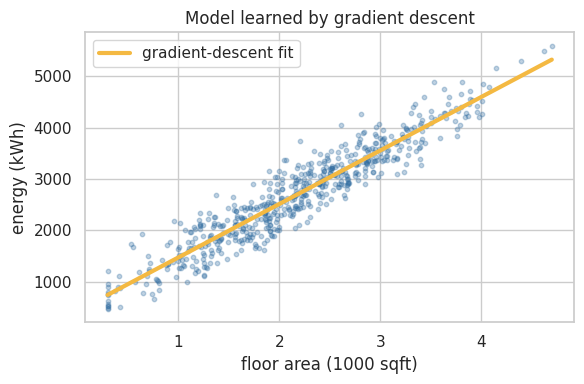

In [60]:

# Plot the fitted line over the data
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x, y, s=10, alpha=0.3, color='#2D6A9F')
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, w * xs + b, color='#F4B942', lw=3, label='gradient-descent fit')
ax.set_xlabel('floor area (1000 sqft)'); ax.set_ylabel('energy (kWh)')
ax.legend(); ax.set_title('Model learned by gradient descent')
plt.tight_layout(); plt.show()

In [61]:
w_initial, b_initial = 0.0, 0.0
dw, db = gradients(w_initial, b_initial)
print(f"Initial gradients: dw={dw:.2f}, db={db:.2f}")

lr = 0.1
w_new = w_initial - lr * dw
b_new = b_initial - lr * db
print(f"New w={w_new:.2f}, b={b_new:.2f} after one update step")

mse_initial = mse(w_initial, b_initial)
mse_new = mse(w_new, b_new)
print(f"Initial MSE: {mse_initial:.0f}")
print(f"New MSE: {mse_new:.0f}")

if mse_new < mse_initial:
    print("Loss decreased after one step: PASS")
else:
    print("Loss did not decrease after one step: FAIL")

Initial gradients: dw=-13293.91, db=-5395.34
New w=1329.39, b=539.53 after one update step
Initial MSE: 8176582
New MSE: 699089
Loss decreased after one step: PASS


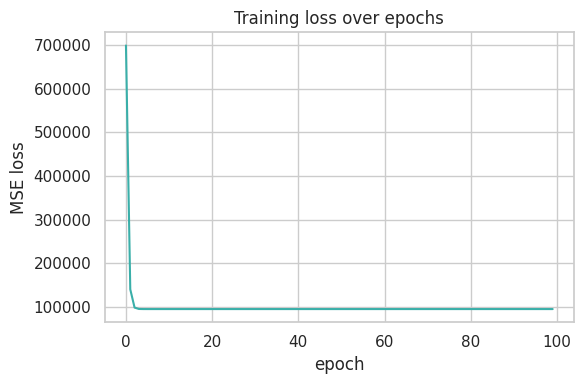

Steep early improvement, then a flat tail = converged.


In [62]:
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hist, color='#3AAFA9')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss')
ax.set_title('Training loss over epochs'); plt.tight_layout(); plt.show()
print('Steep early improvement, then a flat tail = converged.')

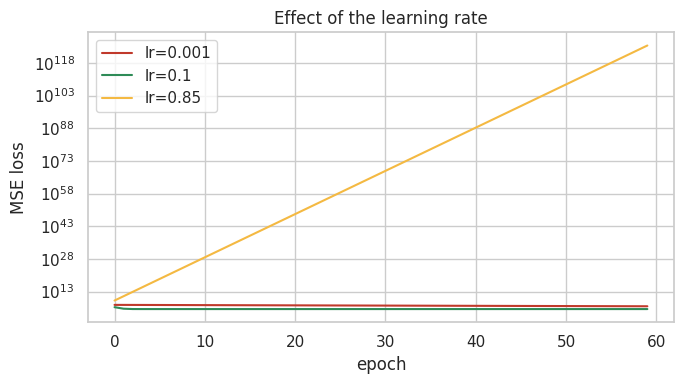

Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.


In [63]:
fig, ax = plt.subplots(figsize=(7, 4))
for lr, col in [(0.001, '#C0392B'), (0.1, '#2E8B57'), (0.85, '#F4B942')]:
    _, _, h = gradient_descent(lr=lr, epochs=60)
    ax.plot(h, label=f'lr={lr}', color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend()
ax.set_title('Effect of the learning rate'); ax.set_yscale('log')
plt.tight_layout(); plt.show()
print('Too small (red): crawls. Good (green): fast & stable. Too large (gold): unstable.')

In [64]:
w_div, b_div, hist_div = gradient_descent(lr=1.5, epochs=30)
print(f'Final loss with large learning rate (lr=1.5): {hist_div[-1]:.0f}')
# Too large a learning rate causes the steps to overshoot the minimum, leading to divergence (loss increases).

Final loss with large learning rate (lr=1.5): 23490994523732618768649221293494432068939190389066275314771460317444532647724318720


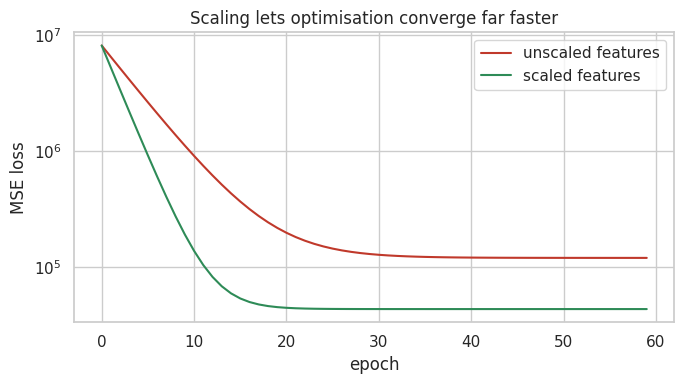

In [65]:
X2 = df[['floor_area_sqft', 'occupancy']].values.astype(float)
yv = df['energy_kwh'].values

def gd_multi(Xm, lr=0.01, epochs=60):
    n, d = Xm.shape
    w = np.zeros(d); b = 0.0; hist = []
    for _ in range(epochs):
        pred = Xm @ w + b
        err = yv - pred
        w += lr * (2 / n) * (Xm.T @ err)
        b += lr * (2 / n) * err.sum()
        hist.append(np.mean(err ** 2))
    return hist

from sklearn.preprocessing import StandardScaler
X2s = StandardScaler().fit_transform(X2)
h_raw = gd_multi(X2, lr=1e-8, epochs=60)     # raw needs a tiny lr or it explodes
h_scaled = gd_multi(X2s, lr=0.1, epochs=60)  # scaled tolerates a healthy lr

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(h_raw, label='unscaled features', color='#C0392B')
ax.plot(h_scaled, label='scaled features', color='#2E8B57')
ax.set_xlabel('epoch'); ax.set_ylabel('MSE loss'); ax.legend(); ax.set_yscale('log')
ax.set_title('Scaling lets optimisation converge far faster')
plt.tight_layout(); plt.show()


In [66]:
print(f"Final loss for unscaled features: {h_raw[-1]:.0f}")
print(f"Final loss for scaled features: {h_scaled[-1]:.0f}")

Final loss for unscaled features: 119138
Final loss for scaled features: 43005


When feature scales are mismatched, the loss function's landscape becomes elongated or 'elliptical'. This means the gradients for different features can have very different magnitudes. If you use a learning rate that is too large for the feature with the largest gradient, it will cause the optimization to overshoot and diverge. Conversely, if you use a tiny learning rate suitable for the largest gradient, it will cause the optimization to crawl very slowly along the dimensions with smaller gradients. Feature scaling transforms this elongated loss bowl into a more spherical shape, allowing a single, larger learning rate to work effectively across all dimensions and converge much faster.

In [67]:
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression().fit(x.reshape(-1, 1), y)
print(f'gradient descent : w={w:.1f}, b={b:.1f}')
print(f'scikit-learn     : w={lr_model.coef_[0]:.1f}, b={lr_model.intercept_:.1f}')
print('They should be very close — our optimiser reached the same minimum.')

gradient descent : w=1042.9, b=426.2
scikit-learn     : w=1042.8, b=426.5
They should be very close — our optimiser reached the same minimum.


In [68]:
building_sqft = 3000
building_x = building_sqft / 1000.0

# Predict using scikit-learn model
skl_prediction = lr_model.predict(np.array([[building_x]]))[0]

# Predict using hand-coded w and b
hand_coded_prediction = w * building_x + b

print(f'Prediction for {building_sqft} sqft building:')
print(f'  Scikit-learn model  : {skl_prediction:.1f} kWh')
print(f'  Hand-coded (w, b)   : {hand_coded_prediction:.1f} kWh')

# Confirm they match closely
if np.isclose(skl_prediction, hand_coded_prediction, atol=0.5):
    print('The predictions are very close: PASS')
else:
    print('The predictions do not match closely: FAIL')

Prediction for 3000 sqft building:
  Scikit-learn model  : 3554.8 kWh
  Hand-coded (w, b)   : 3554.9 kWh
The predictions are very close: PASS
